# `shinka` Tutorial — Interactive LLM-Driven Evolution 🧬 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SakanaAI/ShinkaEvolve/blob/main/examples/shinka_tutorial.ipynb)


This notebook gives a **hands-on** overview of `shinka`, a framework that combines LLMs with evolutionary search. We will focus on the **circle packing** and **novelty generator** examples, explaining the core functionality and how to quickly get started.

We will cover:

* setting up a `shinka` environment with API keys
* giving an overview of the main `shinka` components (islands, archive, mutations, meta-learning)
* writing a fully custom `shinka` configuration and running experiments
* inspecting results and understanding how the evolutionary process unfolded
* using the preconfigured `shinka` configs with the launcher and within Python
* customizing the components of `shinka` and comparing results
* obtaining fully interactive reports with the `shinka` WebUI

## Google Colab setup (optional)
Can be skipped if running locally. Installs the Shinka package inside a Colab instance.

In [ ]:
import os
import sys
import subprocess
from pathlib import Path

# detect colab
try:
    import google.colab  # type: ignore

    in_colab = True
except Exception:
    in_colab = False

repo_name = "ShinkaEvolve"
ssh_url = "git@github.com:SakanaAI/ShinkaEvolve.git"
https_url = "https://github.com/SakanaAI/ShinkaEvolve.git"

cwd = Path.cwd()
repo_root = cwd

if not (repo_root / repo_name).exists():
    for parent in cwd.resolve().parents:
        if (parent / repo_name).exists():
            repo_root = parent
            break

if in_colab:
    root_candidate = Path("/content") / repo_name
    if not root_candidate.exists():
        print("cloning repository...")
        subprocess.check_call(
            ["git", "clone", "--depth", "1", https_url, str(root_candidate)]
        )
    repo_root = root_candidate
    os.chdir(repo_root)
    print("repo_root:", repo_root)
    print("installing package and deps...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "."])
else:
    print("repo_root:", repo_root)

## Environment setup

This cell ensures the repo is importable and optionally loads `.env`
credentials if `python-dotenv` is available. When using Google Colab, please insert your keys in the `additional_llm_keys` list.

In [1]:
import sys
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "shinka").exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / "shinka").exists():
            repo_root = parent
            break

sys.path.insert(0, str(repo_root))
print("repo_root:", repo_root)

env_path = repo_root / ".env"
if env_path.exists():
    try:
        from dotenv import load_dotenv

        load_dotenv(env_path)
        print("loaded .env")
    except Exception as e:
        print("could not load .env:", e)
else:
    print(".env not found, continuing without it)")

# override with your own keys not present in .env file
additional_llm_keys = [
    # "OPENAI_API_KEY=...",
    # "GEMINI_API_KEY=...",
    # "OPENROUTER_API_KEY=...",
    # "DEEPSEEK_API_KEY=...",
    # "AZURE_OPENAI_API_KEY=...",
    # "ANTHROPIC_API_KEY=...",
]

for kv in additional_llm_keys:
    if "=" in kv:
        key, val = kv.split("=", 1)
        if val:
            os.environ[key] = val
            print(f"set {key}")

repo_root: /Users/hlabs/dev/ShinkaEvolve
.env not found, continuing without it)


## 2. Shinka overview

**Population & archive**
- `ProgramDatabase` stores *all* candidates, scores, and metadata.
- An **archive** keeps strong and diverse solutions across **islands**.
- Islands evolve in parallel to avoid premature convergence.

**Mutations**
- `patch_types`: `diff` (targeted edits), `full` (rewrite), `cross`
  (combine two parents).
- LLMs are prompted with task context and inspiration from the archive.

**Novelty**
- Optional semantic checks with embeddings to avoid duplicating ideas:
  `code_embed_sim_threshold`, `embedding_model`, `novelty_llm_models`.

**Meta‑learning**
- Periodic reviews (`meta_rec_interval`) extract patterns into a scratchpad.
- Arm selection for multiple LLMs via bandits (e.g., `UCB1`).


## Writing a fully custom shinka configuration and running experiments on circle packing

We mirror the example in `examples/circle_packing/run_evo.py` but default to
a **small number of generations** and only using smaller models to keep this
tutorial quick and inexpensive.

Feel free to play around and cutomized each component!


In [2]:
# standard shinka imports
import os
import datetime as dt
from time import perf_counter
from pathlib import Path
from shinka.core import ShinkaEvolveRunner, EvolutionConfig
from shinka.database import DatabaseConfig
from shinka.launch import LocalJobConfig

# default circle packing message - can be customized to your liking!
search_task_sys_msg = (
    "You are an expert mathematician specializing in circle packing problems "
    "and computational geometry. The best known result for the sum of radii "
    "when packing 26 circles in a unit square is 2.635.\n\n"
    "Key directions to explore:\n"
    "1. The optimal arrangement likely involves variable-sized circles\n"
    "2. A pure hexagonal arrangement may not be optimal due to edge effects\n"
    "3. The densest known circle packings often use a hybrid approach\n"
    "4. The optimization routine is critically important - simple physics-"
    "based models with carefully tuned parameters\n"
    "5. Consider strategic placement of circles at square corners and edges\n"
    "6. Place larger circles near the center and smaller near the edges\n"
    "7. Math literature suggests special arrangements for specific n\n"
    "8. You can use scipy.optimize to refine radii given fixed centers and "
    "constraints\n\n"
    "Be creative and try to find a new solution."
)

In [4]:
# pick llms based on available keys
llm_models = []
if os.getenv("GEMINI_API_KEY"):
    llm_models.append("gemini-2.5-flash")
if os.getenv("OPENAI_API_KEY"):
    llm_models.append("gpt-5-mini")
if os.getenv("ANTHROPIC_API_KEY"):
    llm_models.append("claude-3-7-sonnet")
elif os.getenv("AWS_ACCESS_KEY_ID") and os.getenv("AWS_REGION"):
    llm_models.append("bedrock/us.anthropic.claude-sonnet-4-20250514-v1:0")
if not llm_models:
    llm_models = ["gpt-5-mini"]  # fallback if no keys detected

# unique experiment directory
timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_tag = f"{timestamp}_weighted_fast"
MAX_EVALUATION_JOBS = 1

evo_config = EvolutionConfig(
    task_sys_msg=search_task_sys_msg,
    # use all three mutation patch types and set prob for all
    patch_types=["diff", "full", "cross"],
    patch_type_probs=[0.6, 0.3, 0.1],
    # runs for 20 generations in sequence
    num_generations=20,
    max_patch_resamples=3,  # resample 3 times if patch fails
    max_patch_attempts=3,  # try 3 times to fix patch via reflection
    # runs locally using the local environment (no loading of conda/docker)
    job_type="local",
    language="python",
    # set LLMs for ensemble
    llm_models=llm_models,
    llm_kwargs=dict(
        temperatures=[0.0, 0.5],  # uniform temperature sampling
        max_tokens=16384,
    ),
    # no meta scratchpad
    meta_rec_interval=None,  # e.g. every 5 generations
    meta_llm_models=None,  # e.g. ["gpt-4.1"]
    meta_llm_kwargs={},  # same as above
    # Set path to initial program relative to repo root
    init_program_path="initial.py",
    results_dir=f"results/circle_packing/{run_tag}",
    # each mutation has three chances of providing a novel solution
    max_novelty_attempts=3,
    # ensemble llm selection among candidates based on past performance
    llm_dynamic_selection=None,  # e.g. "ucb1"
)

db_config = DatabaseConfig(
    db_path="evolution_db.sqlite",
    num_islands=2,
    archive_size=20,
    elite_selection_ratio=0.3,
    num_archive_inspirations=4,
    num_top_k_inspirations=2,
    migration_interval=10,
    migration_rate=0.1,
    island_elitism=True,
    enforce_island_separation=True,
    parent_selection_strategy="weighted",
    parent_selection_lambda=10.0,
)

job_config = LocalJobConfig(eval_program_path="evaluate.py")

print("llm_models:", llm_models)
print("results_dir:", evo_config.results_dir)

llm_models: ['gpt-5-mini']
results_dir: results/circle_packing/20260327_200911_weighted_fast


## Running a minimal circle packing experiment


In [5]:
circle_packing_path = repo_root / "examples" / "circle_packing"
if os.getcwd() != str(circle_packing_path):
    os.chdir(circle_packing_path)
    print("changed working dir to:", circle_packing_path)

runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_evaluation_jobs=MAX_EVALUATION_JOBS,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()

print("completed in", round(toc - tic, 2), "s")

changed working dir to: /Users/hlabs/dev/ShinkaEvolve/examples/circle_packing
  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@   

2026-03-27 20:12:13 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-03-27 20:12:13 - shinka.core.async_runner - INFO -    • CPU cores: 8

2026-03-27 20:12:13 - shinka.core.async_runner - INFO -    • Memory: 24.0 GB

2026-03-27 20:12:13 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-03-27 20:56:58 - shinka.core.async_runner - INFO - ----------------------------------------

2026-03-27 20:56:58 - shinka.database.dbase - INFO - Updating tracked best program from 'None' to                  
'297488c0-3329-407f-aa2c-527c6696c5b7'.

        Program Database Summary                       Best Program              
╭────────────────────┬─────────────────╮ ╭────────────────┬─────────────────────╮
│ Metric             │ Value           │ │ Attribute      │ Value               │
├────────────────────┼─────────────────┤ ├────────────────┼─────────────────────┤
│ Overall Best Score │ 2.47            │ │ ID             │ 297488c0...         │
│ Total Programs     │ 21              │ │ Generation     │ 10                  │
│ Correct Programs   │ 19 / 21 (90%)   │ │ Complexity     │ 1.00                │
│ Archived Programs  │ 19 / 20 (95%)   │ │ Embedding[0]   │ N/A                 │
│ Island Populations │ I0: 10 | I1: 11 │ │ Metric: Score  │ 2.47                │
│ Migration Policy   │ 10G, 10%(E)     │ │ Timestamp      │ 2026-03-27 20:30:44 │
╰────────────────────┴─────────────────╯ ╰────────────────┴─────────────────────╯
          Cost & Stats Summary                                                   
╭────────────────────────┬─────────────╮                                         
│ Metric                 │ Value       │                                         
├────────────────────────┼─────────────┤                                         
│ Total API Cost         │ $0.32       │                                         
│ Total Embedding Cost   │ $0.00       │                                         
│ Total Novelty Cost     │ $0.00       │                                         
│ Total Meta Cost        │ $0.00       │                                         
│ Total Combined Cost    │ $0.32       │                                         
│ Total Compute          │ 0h 17m 12s  │                                         
╰────────────────────────┴─────────────╯

                                            Top 10 Best Performing Programs                                        
╭──────┬──────┬────┬────────┬──────────┬────────────────────────────────┬────────┬────────┬────────┬───────────────
│ Rank │ Gen  │ ✓… │  Score │ Complex… │ Patch Name                     │ Type   │ Island │ Child… │ Timestamp     
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #1  │  10  │ ✓  │  2.467 │      1.0 │ add_corner_seeds_and_multiscal │ diff   │   I0   │      1 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:30:44      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #2  │  12  │ ✓  │  2.467 │      1.0 │ local_nelder_mead_refinement   │ diff   │   I0   │      0 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:37:14      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #3  │  6   │ ✓  │  2.463 │      1.0 │ sa_with_cur_and_targeted_moves │ diff   │   I0   │      2 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:21:34      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #4  │  5   │ ✓  │  2.451 │      1.0 │ sa_current_state_and_radius_bi │ diff   │   I0   │      2 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:19:17      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #5  │  7   │ ✓  │  2.451 │      1.0 │ add_directional_line_search_re │ diff   │   I0   │      1 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:24:27      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #6  │  1   │ ✓  │  2.343 │      1.0 │ lp_simulated_annealing         │ full   │   I1   │      4 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:13:40      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #7  │  15  │ ✓  │  2.328 │      1.0 │ seed_corners_and_edge_seeding_ │ diff   │   I0   │      0 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:43:23      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #8  │  18  │ ✓  │  2.324 │      1.0 │ multiscale_coordinate_ascent   │ full   │   I0   │      0 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:52:10      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│  #9  │  13  │ ✓  │  2.306 │      1.0 │ directed_repulsion_and_more_se │ diff   │   I1   │      1 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:39:14      
├──────┼──────┼────┼────────┼──────────┼────────────────────────────────┼────────┼────────┼────────┼───────────────
│ #10  │  14  │ ✓  │  2.306 │      1.0 │ add_local_minimize_refinement  │ diff   │   I1   │      1 │ 2026-03-27    
│      │      │    │        │          │                                │        │        │        │ 20:41:53      
╰──────┴──────┴────┴────────┴──────────┴────────────────────────────────┴────────┴────────┴────────┴───────────────

completed in 2685.1 s


### Inspecting the results

Loading and plotting the evolution trajectory and the lineage tree of the best solution.


In [6]:
results_root

NameError: name 'results_root' is not defined

In [7]:
import matplotlib.pyplot as plt

from shinka.utils import load_programs_to_df
from shinka.plots import plot_lineage_tree, plot_evals_performance


results_root = Path(runner.results_dir)

task_name = "Circle Packing with shinka"
if os.path.exists(f"{results_root}/{results_root}/evolution_db.sqlite"):
    db_root = results_root / results_root
else:
    db_root = results_root
print(db_root)

#df = load_programs_to_df(f"{db_root}/evolution_db.sqlite")
df = load_programs_to_df(f"{db_root}/programs.sqlite")

results/circle_packing/20260327_200911_weighted_fast
Total program rows: 21
Correct program rows: 19
Total cost: $0.32
Avg cost per program: $0.02


GraphViz not available, using hierarchical layout


/Users/hlabs/dev/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/hlabs/dev/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/hlabs/dev/ShinkaEvolve/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor

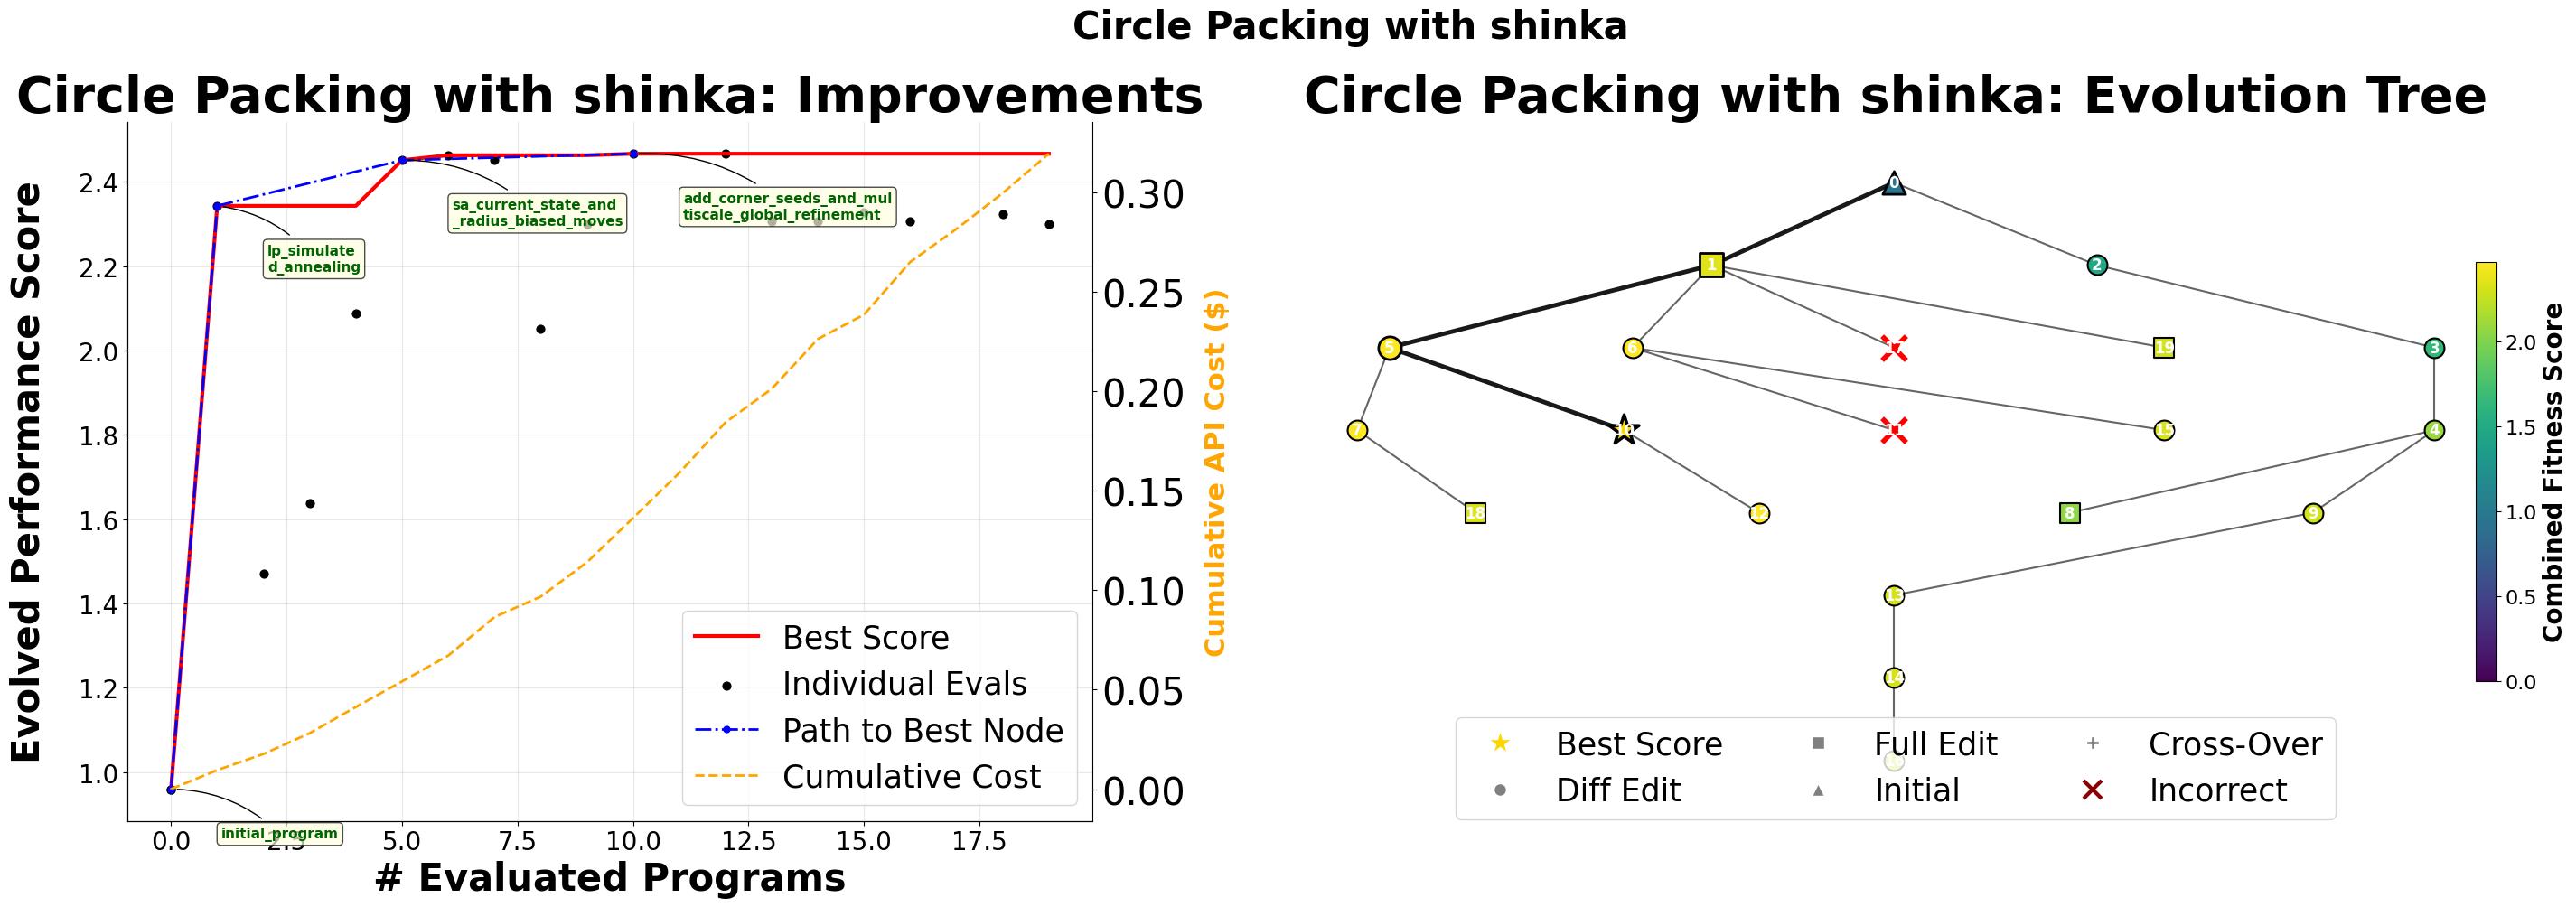

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={"width_ratios": [1, 1.5]})

fig.suptitle(
    f"{task_name}",
    fontsize=30,
    weight="bold",
    y=1,
)

plot_evals_performance(df, f"{task_name}: Improvements", fig, axs[0])
plot_lineage_tree(df, f"{task_name}: Evolution Tree", fig, axs[1])

plt.tight_layout()


### Comparing parent selection strategies

Lets ablate one of the critical components of `shinka`, the parent selection 
strategy and compare the results


In [ ]:
import copy

db_config_uniform = copy.deepcopy(db_config)
db_config_uniform.parent_selection_strategy = "uniform"

evo_config_uniform = copy.deepcopy(evo_config)
timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_tag = f"{timestamp}_unweighted_fast"
evo_config_uniform.results_dir = run_tag


circle_packing_path = repo_root / "examples" / "circle_packing"
if os.getcwd() != str(circle_packing_path):
    os.chdir(circle_packing_path)
    print("changed working dir to:", circle_packing_path)

runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    max_evaluation_jobs=MAX_EVALUATION_JOBS,
    verbose=True,
)

tic = perf_counter()
await runner.run_async()
toc = perf_counter()

print("completed in", round(toc - tic, 2), "s")

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-03-28 12:03:08 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-03-28 12:03:08 - shinka.core.async_runner - INFO -    • CPU cores: 8

2026-03-28 12:03:08 - shinka.core.async_runner - INFO -    • Memory: 24.0 GB

2026-03-28 12:03:08 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-03-28 12:03:09 - shinka.core.async_runner - INFO - Verifying database is ready for sampling...

2026-03-28 12:03:09 - shinka.core.async_runner - INFO - Database ready - 21 program(s) available for sampling

2026-03-28 12:03:09 - shinka.core.async_runner - INFO - Database verification completed - ready for proposal       
generation

2026-03-28 12:03:09 - shinka.core.async_runner - INFO - 🔄 Job monitor task started

2026-03-28 12:03:09 - shinka.core.async_runner - INFO - Proposal target=1 (sampling_ewma=0.00s,                    
evaluation_ewma=0.00s, timing_samples=0, active_proposals=0, running_jobs=0)

In [ ]:
results_root_unweighted = Path(runner.results_dir)
if os.path.exists(
    f"{results_root_unweighted}/{results_root_unweighted}/evolution_db.sqlite"
):
    db_root = results_root_unweighted / results_root_unweighted
else:
    db_root = results_root_unweighted

task_name = "Shinka w/o parent weighting"
#df = load_programs_to_df(f"{db_root}/evolution_db.sqlite")
df = load_programs_to_df(f"{db_root}/programs.sqlite")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={"width_ratios": [1, 1.5]})

fig.suptitle(
    f"{task_name}",
    fontsize=30,
    weight="bold",
    y=1,
)

plot_evals_performance(df, f"{task_name}: Improvements", fig, axs[0])
plot_lineage_tree(df, f"{task_name}: Evolution Tree", fig, axs[1])

plt.tight_layout()


## Launcher and preconfigured `shinka` configs


`shinka` provides many effective preset configurations to run experiments.
You can mix and match any of the task and `shinka` configurations using the 
`shinka` launcher:

```bash
shinka_launch \
    task=circle_packing \
    database=island_large \
    evolution=small_budget \
    cluster=local \
    evo_config.num_generations=10 \
    db_config.num_archive_inspirations=2 \
    variant_suffix="_fast"
```

You can also define a new or use an existing experiment variant in 
`shinka/configs/variant/` e.g.,:
```bash
shinka_launch variant=circle_packing_example
```

You can also load the presets and use them in conjunction with Python api, with 
 in a few lines of code:

```py
from shinka.launch.utils import build_cfgs_from_python

launcher_args = [
    "variant=circle_packing_example",
]

job_cfg, db_cfg, evo_cfg, cfg = build_cfgs_from_python(*launcher_args)

evo_runner = ShinkaEvolveRunner(
    evo_config=evo_cfg,
    job_config=job_cfg,
    db_config=db_cfg,
    max_evaluation_jobs=cfg.max_evaluation_jobs,
    max_proposal_jobs=cfg.max_proposal_jobs,
    max_db_workers=cfg.max_db_workers,
    verbose=cfg.verbose,
)
await evo_runner.run_async()
```

## Novelty generator example modifying preconfigured configurations

This example showcases how `shinka` can be extended with open-ended  **LLM-as-a-judge evaluation** to go beyond predefined performance metrics. The evaluation function using large language models as critical judges to output a **final novelty score** score quantifying diverse, meaningful, and inspirational are the outputs of an LLM generated function:

```py
def generate_novelty(rng: int) -> str:
    ...
```

Let's load and customize the preset configurations for this task using the
Python api:

In [18]:
from shinka.utils.utils_hydra import build_cfgs_from_python
from shinka.core import ShinkaEvolveRunner


# command line configs can be overridden both with lists of arguments or a
# Python dictionary of keyword arguments that will be converted to the
# appropriate arguments

launcher_args = [
    "variant=novelty_generator_example",
    "database=island_small",
    "evolution=small_budget",
    "evo_config.num_generations=10",
]

launcher_kwargs = {
    "evo_config.llm_models": ["gpt-5-mini"],
    "evaluate_function.llm_judge_names": [
        "bedrock/us.anthropic.claude-sonnet-4-20250514-v1:0"
    ],
}

if os.getcwd() != str(repo_root):
    os.chdir(repo_root)
    print("changed working dir to:", repo_root)

job_cfg, db_cfg, evo_cfg, cfg = build_cfgs_from_python(
    *launcher_args, **launcher_kwargs
)

changed working dir to: /Users/hlabs/dev/ShinkaEvolve


In [19]:
evo_runner = ShinkaEvolveRunner(
    evo_config=evo_cfg,
    job_config=job_cfg,
    db_config=db_cfg,
    max_evaluation_jobs=cfg.max_evaluation_jobs,
    max_proposal_jobs=cfg.max_proposal_jobs,
    max_db_workers=cfg.max_db_workers,
    verbose=cfg.verbose,
)
await evo_runner.run_async()

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-03-27 19:07:26 - shinka.core.async_runner - INFO -                                                            
================================================================================

2026-03-27 19:07:26 - shinka.core.async_runner - INFO - ASYNC EVOLUTION RUN STARTED

2026-03-27 19:07:26 - shinka.core.async_runner - INFO -                                                            
================================================================================

2026-03-27 19:07:26 - shinka.core.async_runner - INFO - Max evaluation jobs: 1

...

2026-03-27 19:17:38 - shinka.database.dbase - INFO - Successfully updated embedding features for 11 programs.

2026-03-27 19:17:38 - shinka.database.async_dbase - INFO - Background embedding recomputation completed

2026-03-27 19:17:38 - shinka.database.async_dbase - INFO - Final embedding and cluster recomputation complete.

2026-03-27 19:17:39 - shinka.database.async_dbase - INFO - 🔧 Closing async database with monitoring...

2026-03-27 19:17:39 - shinka.database.async_dbase - INFO - Async database closed

### Inpecting results and loading final function

Total program rows: 11
Correct program rows: 0
Total cost: $0.09
Avg cost per program: $0.01
GraphViz not available, using hierarchical layout


/Users/hlabs/dev/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/hlabs/dev/ShinkaEvolve/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  node_collection = ax.scatter(


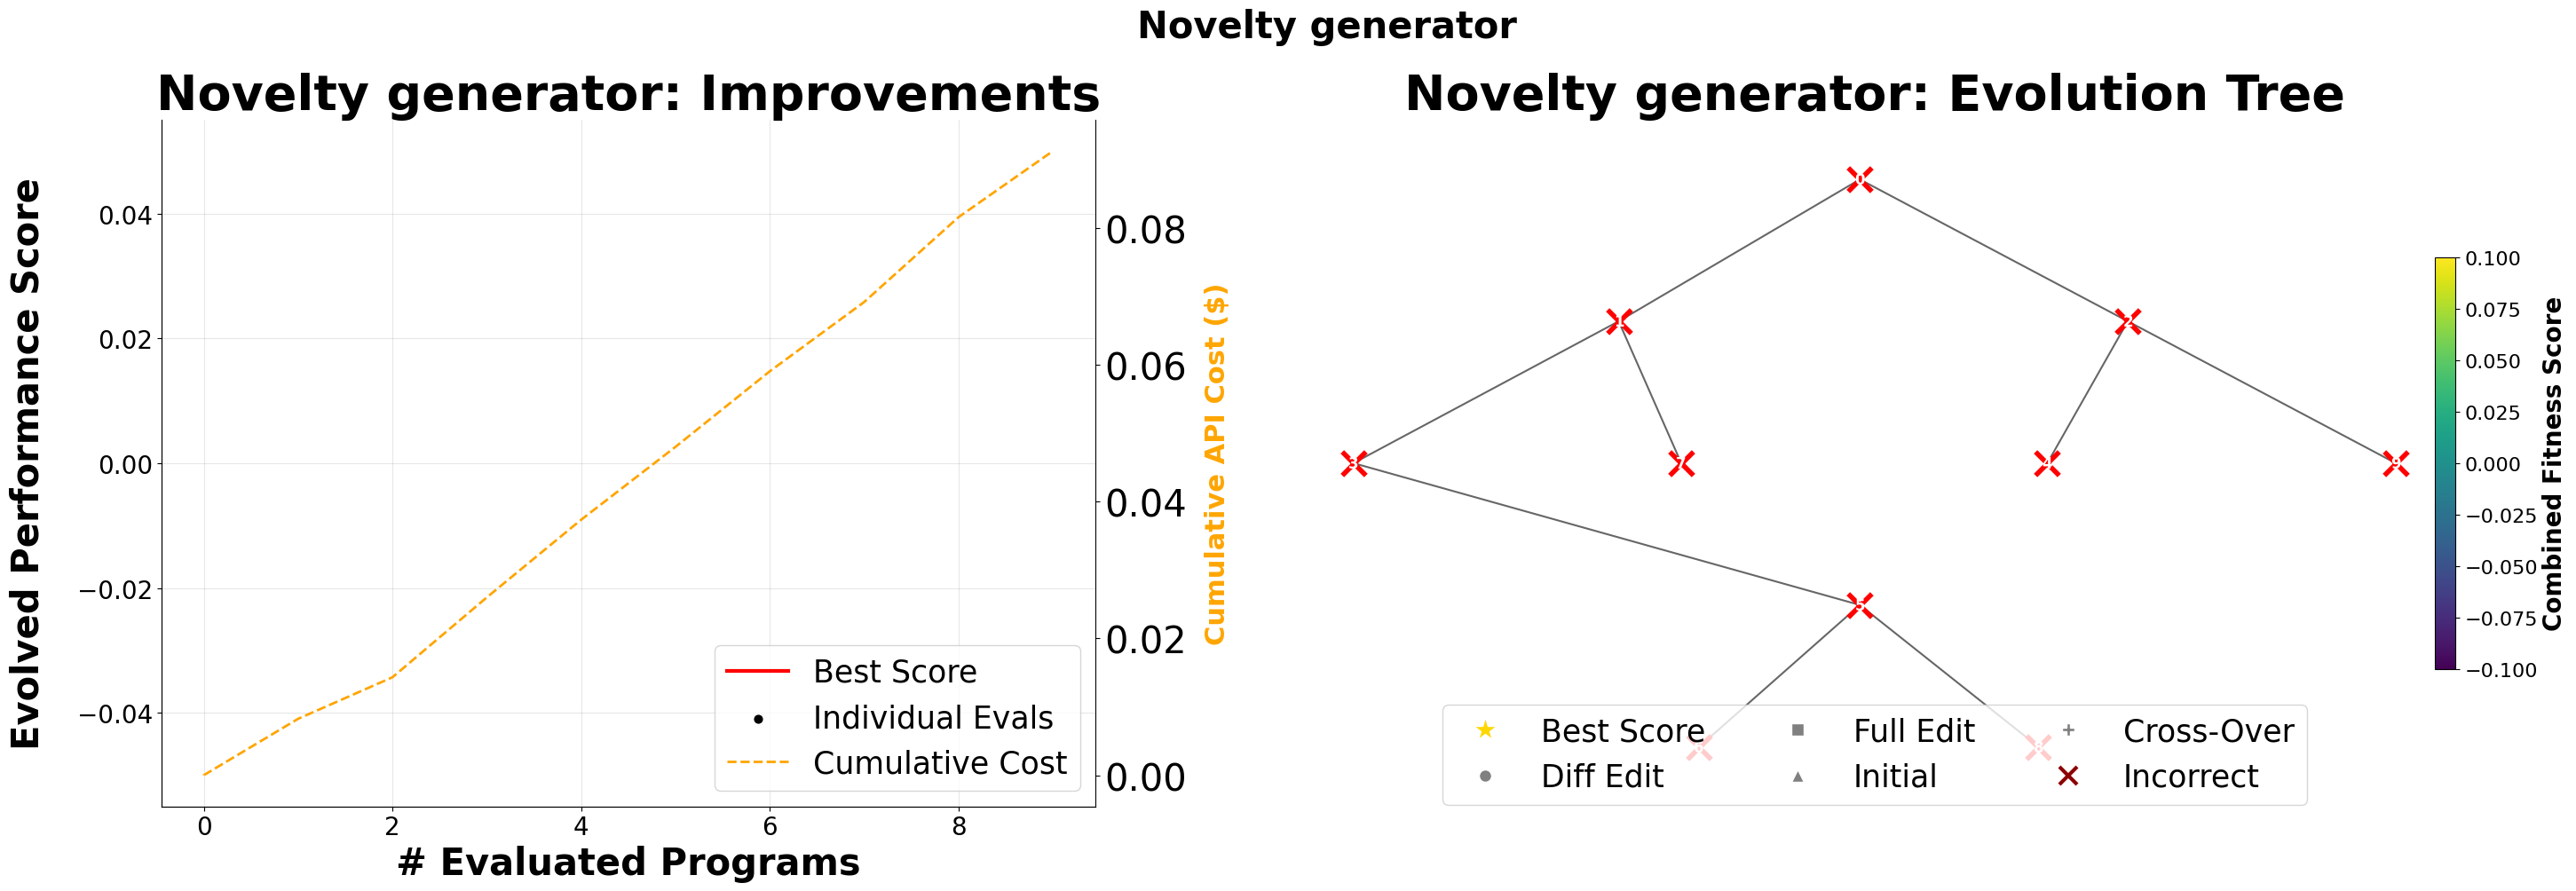

In [21]:
import matplotlib.pyplot as plt

from shinka.utils import load_programs_to_df
from shinka.plots import plot_lineage_tree, plot_evals_performance

results_root = Path(evo_runner.results_dir)

task_name = "Novelty generator"
if os.path.exists(f"{results_root}/{results_root}/evolution_db.sqlite"):
    db_root = results_root / results_root
else:
    db_root = results_root

#df = load_programs_to_df(f"{db_root}/evolution_db.sqlite")
df = load_programs_to_df(f"{db_root}/programs.sqlite")
fig, axs = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={"width_ratios": [1, 1.5]})

fig.suptitle(
    f"{task_name}",
    fontsize=30,
    weight="bold",
    y=1,
)

plot_evals_performance(df, f"{task_name}: Improvements", fig, axs[0])
plot_lineage_tree(df, f"{task_name}: Evolution Tree", fig, axs[1])

plt.tight_layout()


In [23]:
import importlib.util
from rich.console import Console

console = Console()

program_path = results_root / "best/main.py"
spec = importlib.util.spec_from_file_location("program", program_path)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module at {program_path}")

module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

test_inputs = [1, 2, 3]
novel_outputs = module.run_experiment(test_inputs)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/hlabs/dev/ShinkaEvolve/results/shinka_novelty_generator_llm_judge/2026.03.27190701_example/best/main.py'

### Customizing the novelty generator

Let's do some customization of the novelty generator example:
- let's provide more explicit guidance to the `shinka` agents with the system prompt
- let's only use `full` mutations to incentivize more diversity
- let's try using claude instead of gpt

In [ ]:
# new system prompt specifically asking the shinka agents to generate aiscii
# art with procedural generations
new_system_prompt = (
    "Make a python function that takes as input a random integer and produces "
    "ASCII art that is cool, novel, and visually engaging. The art should be "
    "generated procedurally, with the random input seed controlling structures, "
    "patterns, and variations. Depending on its input, each output should be "
    "diverse from all other outputs produced with different inputs. Please, call "
    'this function "def generate_novelty(rng: int) -> str"\n\n'
    "Different judges will evaluate how 1) diverse, 2) meaningful, and 3) "
    "inspirational the generated ASCII art pieces are for different random seeds. "
    "These three criteria will be used to assign your function a "
    '"final_novelty_score" for each judge. Only functions excelling across all '
    'three dimensions will achieve a high "final_novelty_score".\n\n'
    "Now bring out your creativity, focus on procedural ASCII art, and surprise us!"
)

launcher_args = [
    "variant=novelty_generator_example",
    "database=island_small",
    "evolution=small_budget",
    "evo_config.num_generations=10",
]

launcher_kwargs = {
    "evo_config.llm_models": ["bedrock/us.anthropic.claude-sonnet-4-20250514-v1:0"],
    "evaluate_function.llm_judge_names": [
        "bedrock/us.anthropic.claude-sonnet-4-20250514-v1:0"
    ],
    "evo_config.patch_types": ["full"],
    "evo_config.patch_type_probs": [1],
}


job_cfg, db_cfg, evo_cfg, cfg = build_cfgs_from_python(
    *launcher_args, **launcher_kwargs
)

In [ ]:
evo_runner = ShinkaEvolveRunner(
    evo_config=evo_cfg,
    job_config=job_cfg,
    db_config=db_cfg,
    max_evaluation_jobs=cfg.max_evaluation_jobs,
    max_proposal_jobs=cfg.max_proposal_jobs,
    max_db_workers=cfg.max_db_workers,
    verbose=cfg.verbose,
)
await evo_runner.run_async()

### Inpecting results of our custom implementation

In [ ]:
results_root = Path(evo_runner.results_dir)

task_name = "Novelty generator"
if os.path.exists(f"{results_root}/{results_root}/evolution_db.sqlite"):
    db_root = results_root / results_root
else:
    db_root = results_root

df = load_programs_to_df(f"{db_root}/evolution_db.sqlite")
fig, axs = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={"width_ratios": [1, 1.5]})

fig.suptitle(
    f"{task_name}",
    fontsize=30,
    weight="bold",
    y=1,
)

plot_improvement(df, f"{task_name}: Improvements", fig, axs[0])
plot_lineage_tree(df, f"{task_name}: Evolution Tree", fig, axs[1])

plt.tight_layout()

In [ ]:
console = Console()

program_path = results_root / "best/main.py"
spec = importlib.util.spec_from_file_location("program", program_path)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module at {program_path}")

module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

test_inputs = [1, 2, 3]
novel_outputs = module.run_experiment(test_inputs)

## Visualizing your runs with the WebUI for a full report of the evolutionary process

### WebUI
On the **remote** machine where the run is stored:
```bash
shinka_visualize --port 8888
```

On your **local** machine (if **remote** != **local**):
```bash
ssh -vvv -L 8888:localhost:8888 your_user@slurm-cluster
```
Then open <http://localhost:8888/> to browse runs.

The following cells launch WebUI when using `shinka` on a local setup:

In [ ]:
import sys, subprocess, time

# start the webui as a background process
webui_proc = subprocess.Popen(
    ["shinka_visualize", "--port", "8888", "--open"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

# wait briefly so server has time to start
time.sleep(3)
print("webui started on http://127.0.0.1:8888")

In [ ]:
from IPython.display import IFrame, display

display(IFrame(src="http://127.0.0.1:8888", width="100%", height=800))

In [ ]:
webui_proc.terminate()